# ML1 Programming Assignment — Fruits-360

**Run this notebook from the project root** (same folder as `classes.txt` and `data/Fruit-Images-Dataset/`).

- **Dataset:** [Fruit-360 on GitHub](https://github.com/Horea94/Fruit-Images-Dataset) or Kaggle [moltean/fruits](https://www.kaggle.com/datasets/moltean/fruits) — use `Training/` and `Test/` for your **10 assigned classes** (classes with **>400** training images per the brief).
- **Dependencies:** OpenCV (SIFT), scikit-learn, matplotlib, **TensorFlow/Keras** (Question 4), **PyTorch + torchvision** (Questions 5–6). Python 3.10–3.12 is recommended if TensorFlow fails to install.
- **Outputs:** figures and JSON summaries under `outputs/`.


## Question 1 — Dataset and assigned classes (brief §1)

You must **(a)** use **10 assigned classes** and **(b)** download (or obtain) **Training** and **Test** images for those classes from Fruits-360.

The code below maps each display name (same order as `classes.txt`) to the **folder name** under `Training/` and `Test/`. If your local dataset uses different folder names, edit `CLASS_FOLDER_BY_SHORT_NAME` in the setup cell.


## Setup — Imports, paths, helpers, and loading splits

Run this cell once before Questions 2–7.


In [1]:

import json
import os
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().resolve()
_env_root = os.environ.get("FRUIT360_DATA_ROOT", "").strip()
DATA_ROOT = Path(_env_root) if _env_root else (PROJECT_ROOT / "data" / "Fruit-Images-Dataset")
TRAINING_DIR = DATA_ROOT / "Training"
TEST_DIR = DATA_ROOT / "Test"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_VISUAL_WORDS = 100
SIFT_DESCRIPTOR_DIM = 128
N_SPLITS = 10
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG"}

CLASS_FOLDER_BY_SHORT_NAME = {
    "Crimson Snow": "apple_crimson_snow_1",
    "Golden": "apple_golden_1",
    "Red Delicious": "apple_red_delicios_1",
    "Grape (Blue)": "Grape pink 2",
    "Peach": "Peach 3",
    "Potato Red": "Onion Red 2",
    "Beetroot Red": "Cherry 3",
    "Mandarine": "Orange 2",
    "Pineapple": "Papaya 2",
    "Rambutan": "Plum 5",
}

cnn_test_error = None
best_ep_cnn = None
alex_5bc_best = None
alex_5de_test = None
alex_ft_best = None
best_svm_test = None
svm_best = {"kernel": "linear", "C": 1.0}


def list_images(folder: Path) -> list[Path]:
    if not folder.is_dir():
        raise FileNotFoundError(f"Missing folder: {folder}")
    return [p for p in sorted(folder.iterdir()) if p.is_file() and p.suffix in IMAGE_EXTENSIONS]


def load_split_paths(min_train_images: int = 400):
    short_names = list(CLASS_FOLDER_BY_SHORT_NAME.keys())
    name_to_idx = {n: i for i, n in enumerate(short_names)}
    train_paths, train_labels = [], []
    test_paths, test_labels = [], []
    missing_train, missing_test = [], []
    for short, folder_name in CLASS_FOLDER_BY_SHORT_NAME.items():
        tr_dir, te_dir = TRAINING_DIR / folder_name, TEST_DIR / folder_name
        if not tr_dir.is_dir():
            missing_train.append(folder_name)
            continue
        if not te_dir.is_dir():
            missing_test.append(folder_name)
            continue
        tr_imgs, te_imgs = list_images(tr_dir), list_images(te_dir)
        if len(tr_imgs) < min_train_images:
            warnings.warn(
                f"{folder_name}: only {len(tr_imgs)} training images (assignment suggests >{min_train_images})."
            )
        idx = name_to_idx[short]
        train_paths.extend(tr_imgs)
        train_labels.extend([idx] * len(tr_imgs))
        test_paths.extend(te_imgs)
        test_labels.extend([idx] * len(te_imgs))
    if missing_train or missing_test:
        raise FileNotFoundError(
            "Missing class folders.\n"
            f"Dataset root: {TRAINING_DIR.parent}\n"
            + (f"Training: {missing_train}\n" if missing_train else "")
            + (f"Test: {missing_test}\n" if missing_test else "")
            + "Edit CLASS_FOLDER_BY_SHORT_NAME in this cell."
        )
    return (
        train_paths,
        np.array(train_labels, dtype=np.int64),
        test_paths,
        np.array(test_labels, dtype=np.int64),
        short_names,
    )


def load_rgb_array(paths: list[Path], size=(100, 100)) -> np.ndarray:
    h, w = size
    out = np.zeros((len(paths), h, w, 3), dtype=np.float32)
    for i, p in enumerate(paths):
        bgr = cv2.imread(str(p))
        if bgr is None:
            raise ValueError(f"Could not read: {p}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        if rgb.shape[0] != h or rgb.shape[1] != w:
            rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        out[i] = rgb.astype(np.float32) / 255.0
    return out


def read_gray(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path))
    if bgr is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)


def extract_sift(sift, gray: np.ndarray):
    kps, des = sift.detectAndCompute(gray, None)
    if des is None:
        return [], np.empty((0, SIFT_DESCRIPTOR_DIM), dtype=np.float32)
    return list(kps), des.astype(np.float32)


if not TRAINING_DIR.is_dir() or not TEST_DIR.is_dir():
    raise FileNotFoundError(f"Expected Training/ and Test/ under {DATA_ROOT}")

train_paths, y_train, test_paths, y_test, SHORT_NAMES = load_split_paths()
print("Train images:", len(train_paths), "| Test images:", len(test_paths), "| Classes:", len(SHORT_NAMES))


C:\Users\USER\AppData\Local\Temp\ipykernel_14464\949909380.py:76: UserWarning: apple_crimson_snow_1: only 318 training images (assignment suggests >400).
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_14464\949909380.py:76: UserWarning: apple_golden_1: only 308 training images (assignment suggests >400).
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_14464\949909380.py:76: UserWarning: apple_red_delicios_1: only 300 training images (assignment suggests >400).
  warnings.warn(


Train images: 4367 | Test images: 2170 | Classes: 10


## Question 2 — Bag of visual words (BoVW) and PCA (2 points)

Per the assignment: SIFT descriptors (128-D per keypoint), pool all training keypoints into **KP**, **K-means** with **K = 100**, build a **100-D** histogram per image, form dataset **D**, then **PCA → 2D** for visualization (**without** using class labels in PCA).


### Question 2(a) — SIFT on each training image; plot keypoints on one training image (0.5 pt)

OpenCV SIFT: [tutorial](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html). Each keypoint has a **128-dimensional** descriptor.


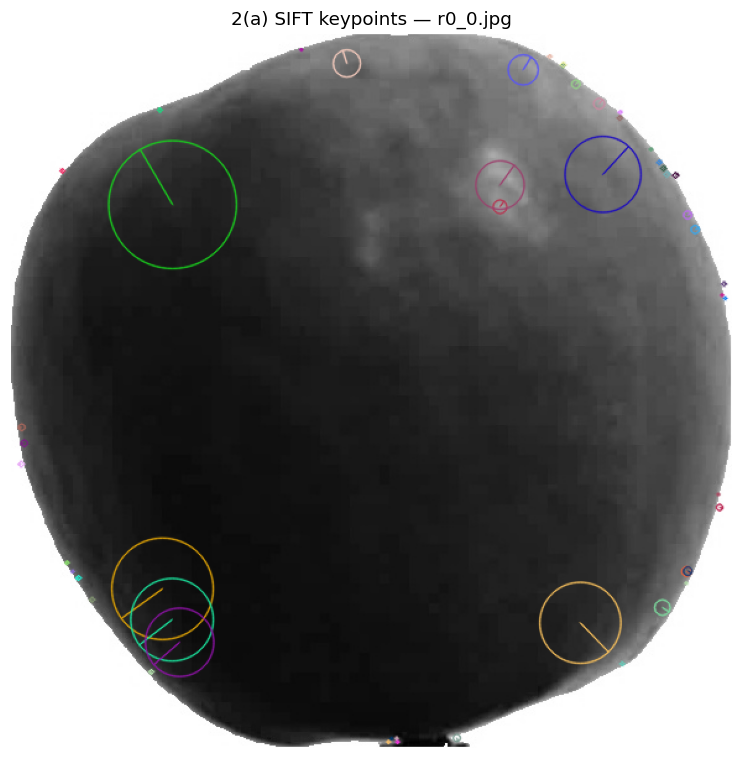

In [2]:

sift = cv2.SIFT_create()
sample_kps, sample_gray, sample_viz_path = [], None, train_paths[0]
for p in train_paths:
    g = read_gray(p)
    kps, _ = extract_sift(sift, g)
    if kps:
        sample_viz_path, sample_kps, sample_gray = p, kps, g
        break
else:
    sample_gray = read_gray(train_paths[0])

vis = cv2.drawKeypoints(
    sample_gray, sample_kps, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
fig0, ax0 = plt.subplots(figsize=(7, 7))
ax0.imshow(vis, cmap="gray")
ax0.set_title(f"2(a) SIFT keypoints — {sample_viz_path.name}")
ax0.axis("off")
fig0.tight_layout()
fig0.savefig(OUTPUT_DIR / "q2a_sift_keypoints.png", dpi=150)
plt.show()


### Question 2(b)–(e) — Keypoint dataset KP; K-means (K=100); 100-D BoVW vectors; dataset D

- **(b)** **KP** = all descriptors from all **training** images.  
- **(c)** **K-means** with **K = 100** on KP ([sklearn clustering](https://scikit-learn.org/stable/modules/clustering.html)).  
- **(d)** For each image, count how many keypoints fall in each cluster → **100-D** histogram (example in the PDF).  
- **(e)** **D** = matrix of those vectors for all training images (rows = images).


In [3]:

all_descriptors, per_image_descriptors = [], []
for p in train_paths:
    gray = read_gray(p)
    _, des = extract_sift(sift, gray)
    per_image_descriptors.append(des)
    if des.shape[0] > 0:
        all_descriptors.append(des)

kp_matrix = np.vstack(all_descriptors)
print("2(b) Total descriptors in KP:", kp_matrix.shape)

kmeans = MiniBatchKMeans(
    n_clusters=N_VISUAL_WORDS, random_state=RANDOM_STATE, batch_size=4096, n_init=3, max_iter=100
)
kmeans.fit(kp_matrix)
print("2(c) K-means fitted with K =", N_VISUAL_WORDS)

histograms = np.zeros((len(train_paths), N_VISUAL_WORDS), dtype=np.float64)
for i, des in enumerate(per_image_descriptors):
    if des.shape[0] == 0:
        continue
    lbl = kmeans.predict(des)
    histograms[i] = np.bincount(lbl, minlength=N_VISUAL_WORDS)
row_sums = histograms.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
histograms = histograms / row_sums
print("2(d)–(e) Dataset D shape (train images × 100):", histograms.shape)


def histograms_for_paths(paths, km, sf):
    h = np.zeros((len(paths), N_VISUAL_WORDS), dtype=np.float64)
    for i, p in enumerate(paths):
        _, des = extract_sift(sf, read_gray(p))
        if des.shape[0] == 0:
            continue
        h[i] = np.bincount(km.predict(des), minlength=N_VISUAL_WORDS)
    rs = h.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1.0
    return h / rs


bovw_pack = {"histograms_train": histograms, "y_train": y_train, "kmeans": kmeans, "sift": sift}


2(b) Total descriptors in KP: (524138, 128)
2(c) K-means fitted with K = 100
2(d)–(e) Dataset D shape (train images × 100): (4367, 100)


### Question 2(f) — PCA on D ([sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html))

**(i)** Reduce **D** to **2** dimensions. **Do not** pass class labels into `PCA.fit`.  
**(ii)** Scatter plot: **10** distinct colors/markers for the 10 classes (see assignment Figure 2). **(1 pt** total for 2(f) components per rubric**).**


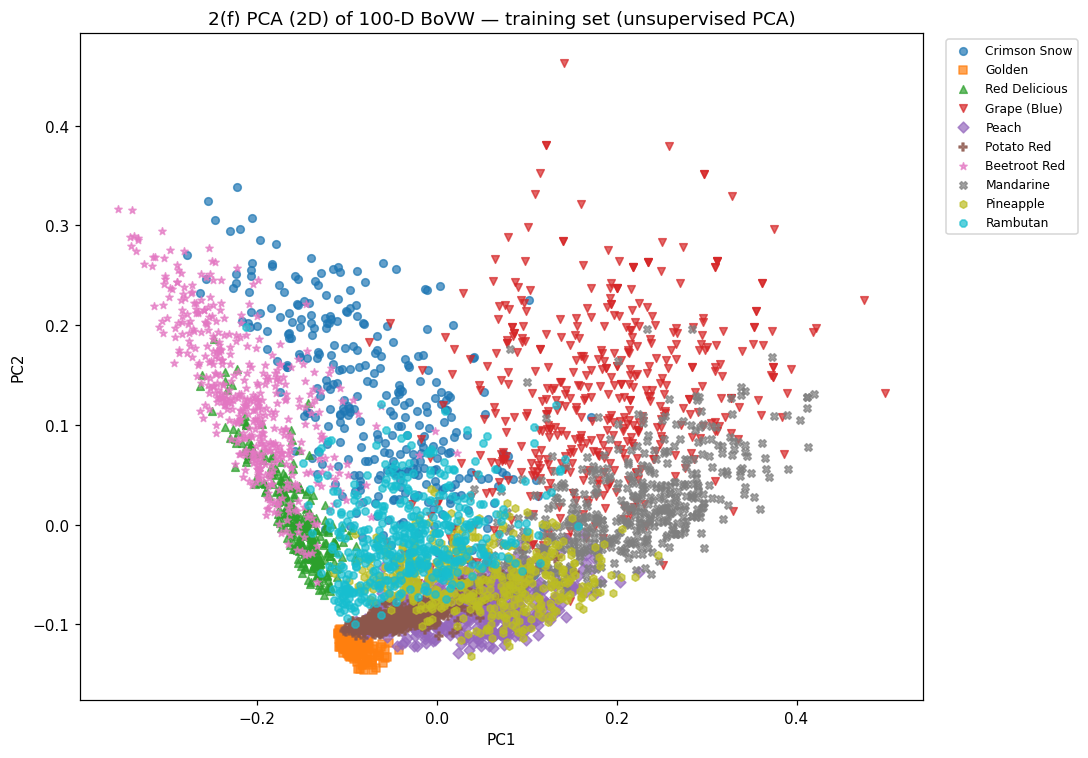

In [4]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
D2 = pca.fit_transform(histograms)

fig, ax = plt.subplots(figsize=(10, 7))
markers = ["o", "s", "^", "v", "D", "P", "*", "X", "h", "8"]
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for c in range(len(SHORT_NAMES)):
    m = y_train == c
    ax.scatter(
        D2[m, 0],
        D2[m, 1],
        c=[colors[c]],
        marker=markers[c % len(markers)],
        label=SHORT_NAMES[c],
        alpha=0.7,
        s=25,
    )
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("2(f) PCA (2D) of 100-D BoVW — training set (unsupervised PCA)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "q2f_pca_bovw.png", dpi=150, bbox_inches="tight")
plt.show()


### Question 2(f)(iii) — Discussion: separability of classes (0.5 pt)

**Your answer (edit this cell):** In the PCA plot above, comment on which classes overlap, which appear more separated, and whether BoVW+PCA suggests linear separability in 2D.


## Question 3 — SVM on BoVW (3 points)

**(a)** Linear SVM (`kernel='linear'`) on the **100-D** BoVW data.  
**(b)** **StratifiedKFold** with **K = 10**.  
**(c)** Try **C ∈ {0.01, 0.1, 1.0, 10, 100}**.  
**(d)** Plot **mean** training and validation **error** with **symmetric error bars** (std across folds); plot **test error** using a model trained on **all** training data ([errorbar example](https://matplotlib.org/stable/gallery/statistics/errorbar_features.html)).  
**(e)** Repeat **(c)**–**(d)** for **`rbf`**, **`poly`**, **`sigmoid`**.  
**(f)** Bar plot of train / validation (with error bars) / test for the **best C per kernel** (best = lowest **test** error from (d)/(e)). **(0.5 pt)**  
**(g)**–**(h)** Short written answers in markdown + printed numbers below.


In [5]:

C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]
KERNELS = ["linear", "rbf", "poly", "sigmoid"]

X_train = np.asarray(bovw_pack["histograms_train"], dtype=np.float64)
y_tr = np.asarray(bovw_pack["y_train"])
X_test_bovw = histograms_for_paths(test_paths, bovw_pack["kmeans"], bovw_pack["sift"])
y_te = np.asarray(y_test)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def svc_factory(kernel: str, C: float) -> SVC:
    kw = {"kernel": kernel, "C": C, "random_state": RANDOM_STATE}
    if kernel in ("rbf", "poly", "sigmoid"):
        kw["gamma"] = "scale"
    return SVC(**kw)


def clf_error(clf, X, y) -> float:
    return float(1.0 - clf.score(X, y))


def svm_grid_for_kernel(kernel: str):
    mean_train, std_train, mean_val, std_val, test_errs = [], [], [], [], []
    for C in C_VALUES:
        fold_tr, fold_va = [], []
        for tr_idx, va_idx in skf.split(X_train, y_tr):
            Xa, Xb = X_train[tr_idx], X_train[va_idx]
            ya, yb = y_tr[tr_idx], y_tr[va_idx]
            clf = svc_factory(kernel, C)
            clf.fit(Xa, ya)
            fold_tr.append(clf_error(clf, Xa, ya))
            fold_va.append(clf_error(clf, Xb, yb))
        mean_train.append(float(np.mean(fold_tr)))
        std_train.append(float(np.std(fold_tr)))
        mean_val.append(float(np.mean(fold_va)))
        std_val.append(float(np.std(fold_va)))
        full = svc_factory(kernel, C)
        full.fit(X_train, y_tr)
        test_errs.append(clf_error(full, X_test_bovw, y_te))
    return {
        "C_VALUES": C_VALUES,
        "mean_train": mean_train,
        "std_train": std_train,
        "mean_val": mean_val,
        "std_val": std_val,
        "test_error": test_errs,
    }


def plot_svm_c_sweep(kernel: str, res: dict):
    x = np.arange(len(C_VALUES))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.errorbar(x, res["mean_train"], yerr=res["std_train"], fmt="-o", capsize=4, label="Train (mean ± std over folds)")
    ax.errorbar(x, res["mean_val"], yerr=res["std_val"], fmt="-s", capsize=4, label="Validation (mean ± std)")
    ax.plot(x, res["test_error"], "-^", color="tab:red", label="Test (model trained on full train)")
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in C_VALUES])
    ax.set_xlabel("C")
    ax.set_ylabel("Error")
    ax.set_title(f"Question 3 — SVM BoVW, kernel = {kernel!r}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"q3_svm_bovw_{kernel}.png", dpi=150)
    plt.show()


results_by_kernel = {}


### Question 3(c)–(d) — Linear kernel (`kernel='linear'`)


In [ ]:

results_by_kernel["linear"] = svm_grid_for_kernel("linear")
plot_svm_c_sweep("linear", results_by_kernel["linear"])


### Question 3(e) — `rbf` kernel (repeat C sweep and plot)


In [ ]:

results_by_kernel["rbf"] = svm_grid_for_kernel("rbf")
plot_svm_c_sweep("rbf", results_by_kernel["rbf"])


### Question 3(e) — `poly` kernel


In [ ]:

results_by_kernel["poly"] = svm_grid_for_kernel("poly")
plot_svm_c_sweep("poly", results_by_kernel["poly"])


### Question 3(e) — `sigmoid` kernel


In [ ]:

results_by_kernel["sigmoid"] = svm_grid_for_kernel("sigmoid")
plot_svm_c_sweep("sigmoid", results_by_kernel["sigmoid"])


### Question 3(f) — Best SVM per kernel (lowest test error over C): train, validation ± bars, test


In [ ]:

best_by_kernel = {}
for kernel in KERNELS:
    te = results_by_kernel[kernel]["test_error"]
    best_i = int(np.argmin(te))
    best_C = C_VALUES[best_i]
    fold_tr, fold_va = [], []
    for tr_idx, va_idx in skf.split(X_train, y_tr):
        Xa, Xb = X_train[tr_idx], X_train[va_idx]
        ya, yb = y_tr[tr_idx], y_tr[va_idx]
        clf = svc_factory(kernel, best_C)
        clf.fit(Xa, ya)
        fold_tr.append(clf_error(clf, Xa, ya))
        fold_va.append(clf_error(clf, Xb, yb))
    full = svc_factory(kernel, best_C)
    full.fit(X_train, y_tr)
    best_by_kernel[kernel] = {
        "best_C": best_C,
        "mean_train": float(np.mean(fold_tr)),
        "std_train": float(np.std(fold_tr)),
        "mean_val": float(np.mean(fold_va)),
        "std_val": float(np.std(fold_va)),
        "test_error": clf_error(full, X_test_bovw, y_te),
    }

xk = np.arange(len(KERNELS))
w = 0.25
fig2, ax2 = plt.subplots(figsize=(10, 4.5))
ax2.bar(
    xk - w,
    [best_by_kernel[k]["mean_train"] for k in KERNELS],
    w,
    yerr=[best_by_kernel[k]["std_train"] for k in KERNELS],
    capsize=3,
    label="Train (CV mean ± std)",
)
ax2.bar(
    xk,
    [best_by_kernel[k]["mean_val"] for k in KERNELS],
    w,
    yerr=[best_by_kernel[k]["std_val"] for k in KERNELS],
    capsize=3,
    label="Validation (CV mean ± std)",
)
ax2.bar(xk + w, [best_by_kernel[k]["test_error"] for k in KERNELS], w, label="Test (full train)", color="tab:red")
ax2.set_xticks(xk)
ax2.set_xticklabels(KERNELS)
ax2.set_ylabel("Error")
ax2.set_title("Question 3(f) — Best SVM per kernel (min test error over C)")
ax2.legend()
ax2.grid(True, axis="y", alpha=0.3)
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / "q3_svm_best_by_kernel.png", dpi=150)
plt.show()

best_kernel = min(best_by_kernel, key=lambda k: best_by_kernel[k]["test_error"])
svm_best = {"kernel": best_kernel, "C": float(best_by_kernel[best_kernel]["best_C"])}
best_svm_test = best_by_kernel[best_kernel]["test_error"]
print("Overall best kernel:", best_kernel, "| C:", svm_best["C"], "| test error:", best_svm_test)

with open(OUTPUT_DIR / "q3_svm_summary.json", "w", encoding="utf-8") as f:
    json.dump({"results_by_kernel": results_by_kernel, "best_by_kernel": best_by_kernel}, f, indent=2)


### Question 3(g) — Validation vs test error (0.25 pt)

**Your answer (edit this cell):** Describe how validation error relates to test error. Does the **test** error fall **within** the **validation mean ± std** bar from cross-validation for the best models?

The next cell prints a small table to support your discussion.


In [ ]:

print("Question 3(g) — best-C models: validation mean ± std vs test error")
print(f"{'Kernel':<10} {'best C':>8} {'val err':>12} {'±std':>10} {'test err':>10} {'test in [val-std,val+std]?'}")
for k in KERNELS:
    b = best_by_kernel[k]
    lo, hi = b["mean_val"] - b["std_val"], b["mean_val"] + b["std_val"]
    te = b["test_error"]
    inside = lo <= te <= hi
    print(
        f"{k:<10} {b['best_C']:>8} {b['mean_val']:>12.4f} {b['std_val']:>10.4f} {te:>10.4f} {inside!s:>24}"
    )


### Question 3(h) — Best C per kernel and best kernel overall (0.25 pt)

**Your answer (edit this cell):** State the **C** used for each kernel at best test error, and which kernel achieved the best classification performance (consistent with Question 3(f)).

Numbers are printed below.


In [ ]:

print("Question 3(h) — best C per kernel (min test error over C grid)")
for k in KERNELS:
    print(f"  {k}: C = {best_by_kernel[k]['best_C']}, test error = {best_by_kernel[k]['test_error']:.4f}")
print(f"Best overall: kernel = {best_kernel!r}, C = {svm_best['C']}, test error = {best_svm_test:.4f}")


## Question 4 — Simple CNN (2 points)

Architecture (assignment):

1. **Two** convolution layers, **8** filters, **3×3**, **ReLU**  
2. **Max pooling** **2×2**  
3. **Flatten**  
4. **Two** fully connected hidden layers with **16** units, **ReLU**  
5. Output **10** units, **softmax**

Train with **Adam**, **categorical cross-entropy**, **≥ 20** epochs; choose a batch size that runs on your machine ([Keras convnet example](https://keras.io/examples/vision/mnist_convnet/)).

**(a)** Stratified **10-fold** CV.  
**(b)** Learning curves: x = epoch, y = **mean** train and validation **error** with **error bars** across folds **(1.25 pt)**.  
**(c)** From the curve, pick the epoch with **minimum mean validation error**; retrain on **all** training data for that many epochs; report **test error** **(0.5 pt)**.  
**(d)** Is the CNN **better** than the **best SVM** from Question 3? **(0.25 pt)**

**Requires TensorFlow.** If import fails, install TF or use Python 3.10–3.12.


### Question 4(a)–(b) — 10-fold CV learning curves (error vs epoch)


In [ ]:

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, backend as K
except ImportError:
    print("TensorFlow not installed — skip Questions 4(b)–(d). pip install tensorflow (Python 3.10–3.12).")
else:
    IMG_SIZE = (100, 100)
    EPOCHS = 20
    BATCH = 32
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    def build_cnn(input_shape=(*IMG_SIZE, 3), num_classes=10):
        m = keras.Sequential(
            [
                layers.Input(shape=input_shape),
                layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
                layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
                layers.MaxPooling2D((2, 2)),
                layers.Flatten(),
                layers.Dense(16, activation="relu"),
                layers.Dense(16, activation="relu"),
                layers.Dense(num_classes, activation="softmax"),
            ],
            name="fruit360_cnn",
        )
        m.compile(optimizer=keras.optimizers.Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
        return m

    X_tr_rgb = load_rgb_array(train_paths, size=IMG_SIZE)
    X_te_rgb = load_rgb_array(test_paths, size=IMG_SIZE)
    y_tr_cat = keras.utils.to_categorical(y_train, 10)
    y_te_cat = keras.utils.to_categorical(y_test, 10)
    skf_c = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    train_err_f = np.zeros((N_SPLITS, EPOCHS))
    val_err_f = np.zeros((N_SPLITS, EPOCHS))
    for fold_idx, (tr_i, va_i) in enumerate(skf_c.split(X_tr_rgb, y_train)):
        K.clear_session()
        model = build_cnn()
        hist = model.fit(
            X_tr_rgb[tr_i],
            y_tr_cat[tr_i],
            validation_data=(X_tr_rgb[va_i], y_tr_cat[va_i]),
            epochs=EPOCHS,
            batch_size=BATCH,
            verbose=0,
        )
        train_err_f[fold_idx] = 1.0 - np.asarray(hist.history["accuracy"], dtype=np.float64)
        val_err_f[fold_idx] = 1.0 - np.asarray(hist.history["val_accuracy"], dtype=np.float64)
    m_tr, s_tr = train_err_f.mean(0), train_err_f.std(0)
    m_va, s_va = val_err_f.mean(0), val_err_f.std(0)
    ep_x = np.arange(1, EPOCHS + 1)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.errorbar(ep_x, m_tr, yerr=s_tr, fmt="-o", capsize=3, label="Train (mean ± std)")
    ax.errorbar(ep_x, m_va, yerr=s_va, fmt="-s", capsize=3, label="Validation (mean ± std)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Error")
    ax.set_title("Question 4(b) — CNN learning curves (10-fold CV)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "q4_cnn_learning_curves.png", dpi=150)
    plt.show()


### Question 4(c) — Retrain on full training set until best epoch; test error


In [ ]:

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import backend as K
except ImportError:
    print("Skipping 4(c): TensorFlow not available.")
else:
    _need = ("m_va", "build_cnn", "X_tr_rgb", "y_tr_cat", "X_te_rgb", "y_te_cat", "BATCH")
    _missing = [n for n in _need if n not in globals()]
    if _missing:
        print("Skipping 4(c): run Question 4(b) first — missing:", ", ".join(_missing))
    else:
        best_ep_cnn = int(np.argmin(m_va)) + 1
        K.clear_session()
        final = build_cnn()
        final.fit(X_tr_rgb, y_tr_cat, epochs=best_ep_cnn, batch_size=BATCH, verbose=0)
        _, acc = final.evaluate(X_te_rgb, y_te_cat, verbose=0)
        cnn_test_error = float(1.0 - acc)
        print(f"Question 4(c) — epoch with min mean val error: {best_ep_cnn} | CNN test error: {cnn_test_error:.4f}")
        with open(OUTPUT_DIR / "q4_cnn_summary.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "best_epoch": best_ep_cnn,
                    "test_error": cnn_test_error,
                    "svm_best_test": (float(best_svm_test) if best_svm_test is not None else None),
                },
                f,
                indent=2,
            )


### Question 4(d) — CNN vs best SVM (0.25 pt)

**Your answer (edit this cell):** After running the cells above, state whether the CNN test error is lower (better) than the best BoVW+SVM test error from Question 3, and by roughly how much.


## Question 5 — Transfer learning: feature extraction with AlexNet (1.5 points)

**(a)** Pretrained AlexNet — report **test accuracy** as requested ([reference](https://medium.com/analytics-vidhya/pytorch-directly-use-pre-trained-alexnet-for-image-classification-)).  
**(b)** Freeze all layers, add/train a **10-class** head for **20** epochs ([transfer learning](https://pyimagesearch.com/2021/10/11/pytorch-transfer-learning-and-image-classification/)).  
**(c)** Plot **train** vs **validation** using the **test set** as validation (per assignment wording); report **best test error**. **(0.5 pt)**  
**(d)** Extract features from the **last convolutional** layer using a **forward hook** ([PyTorch hooks](https://pytorch.org/docs/stable/generated/torch.nn.modules.module.register_module_forward_hook.html)) or torchvision feature extraction.  
**(e)** Train **SVM** on training features using the **kernel** and **C** from **Question 3(h)**; report **train** and **test** errors. **(0.75 pt)**


### Question 5(a) — Pretrained AlexNet: test accuracy (0.25 pt)

The default AlexNet head predicts **1000 ImageNet** classes. Evaluating **argmax** against your **10 fruit labels** is usually **not** semantically meaningful; the assignment still asks for this number — we report it and note the caveat below.


In [ ]:

import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import AlexNet_Weights

BATCH_SIZE = 32
FT_EPOCHS = 20
IMG_NET_SIZE = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def imagenet_tfm():
    return transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(IMG_NET_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )


def paths_to_tensor(paths, tfm):
    return torch.stack([tfm(Image.open(p).convert("RGB")) for p in paths], dim=0)


def err_rate(logits, y):
    return float((logits.argmax(1) != y).float().mean().item())


tfm = imagenet_tfm()
y_te_t = torch.from_numpy(y_test).long().to(device)
w = AlexNet_Weights.IMAGENET1K_V1
model_a = models.alexnet(weights=w).to(device).eval()

correct, n = 0, 0
with torch.no_grad():
    for i in range(0, len(test_paths), BATCH_SIZE):
        xb = paths_to_tensor(test_paths[i : i + BATCH_SIZE], tfm).to(device)
        yb = y_te_t[i : i + BATCH_SIZE]
        correct += int((model_a(xb).argmax(1) == yb).sum().item())
        n += len(test_paths[i : i + BATCH_SIZE])
acc5a = correct / max(n, 1)
print("Question 5(a) — test accuracy (ImageNet logits vs your 10-class labels):", acc5a)
print("(Low accuracy is expected unless labels align with ImageNet indices.)")
with open(OUTPUT_DIR / "q5a_alexnet_pretrained_accuracy.json", "w", encoding="utf-8") as f:
    json.dump({"test_accuracy_image_head_vs_fruit_labels": acc5a}, f, indent=2)


### Question 5(b)–5(c) — Frozen AlexNet + trainable 10-way head; learning curves; best test error


In [ ]:

model = models.alexnet(weights=w).to(device)
model.classifier[6] = nn.Linear(4096, 10)
for p in model.features.parameters():
    p.requires_grad = False
for p in model.classifier[:6].parameters():
    p.requires_grad = False
opt = torch.optim.Adam(list(model.classifier[6].parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss()
X_train_t = paths_to_tensor(train_paths, tfm).to(device)
y_tr_t = torch.from_numpy(y_train).long().to(device)
X_test_t = paths_to_tensor(test_paths, tfm).to(device)

tr_e, te_e = [], []
for _ in range(FT_EPOCHS):
    model.train()
    perm = torch.randperm(len(X_train_t), device=device)
    for i in range(0, len(perm), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        opt.zero_grad()
        crit(model(X_train_t[idx]), y_tr_t[idx]).backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        tr_e.append(err_rate(model(X_train_t), y_tr_t))
        te_e.append(err_rate(model(X_test_t), y_te_t))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, FT_EPOCHS + 1), tr_e, "-o", label="Train error")
ax.plot(range(1, FT_EPOCHS + 1), te_e, "-s", label="Test error (used as validation in brief)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Error")
ax.set_title("Question 5(c) — AlexNet frozen + 10-class head")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "q5bc_alexnet_frozen_head_curves.png", dpi=150)
plt.show()
alex_5bc_best = float(min(te_e))
print("Question 5(c) — best test error over epochs:", alex_5bc_best)


### Question 5(d)–5(e) — Last conv features (forward hook) + SVM with Q3(h) hyperparameters


In [ ]:

model_f = models.alexnet(weights=w).to(device).eval()
hook_out = []


def hook_fn(_m, _inp, out):
    hook_out.append(out.detach())


h = model_f.features[10].register_forward_hook(hook_fn)


def conv5_feats(paths):
    chunks = []
    with torch.no_grad():
        for i in range(0, len(paths), BATCH_SIZE):
            batch = paths[i : i + BATCH_SIZE]
            x = paths_to_tensor(batch, tfm).to(device)
            hook_out.clear()
            _ = model_f.features(x)
            chunks.append(hook_out[0].flatten(1).cpu().numpy())
    return np.vstack(chunks)


Xf_tr = conv5_feats(train_paths)
Xf_te = conv5_feats(test_paths)
h.remove()

kw = {"kernel": svm_best["kernel"], "C": float(svm_best["C"]), "random_state": RANDOM_STATE}
if svm_best["kernel"] in ("rbf", "poly", "sigmoid"):
    kw["gamma"] = "scale"
svm_f = SVC(**kw)
svm_f.fit(Xf_tr, y_train)
tr_f = 1.0 - svm_f.score(Xf_tr, y_train)
te_f = 1.0 - svm_f.score(Xf_te, y_test)
alex_5de_test = float(te_f)
print("Question 5(e) — SVM on conv5 features | kernel =", svm_best["kernel"], "| C =", svm_best["C"])
print("  Train error:", tr_f, "| Test error:", te_f)
with open(OUTPUT_DIR / "q5e_alexnet_conv5_svm.json", "w", encoding="utf-8") as f:
    json.dump(
        {"kernel": svm_best["kernel"], "C": svm_best["C"], "train_error": tr_f, "test_error": te_f},
        f,
        indent=2,
    )


## Question 6 — Fine-tuning AlexNet (1 point)

**(a)** Initialize from **pretrained AlexNet**, train the **10-class** model for **20** epochs (fine-tune).  
**(b)** Plot **train** and **validation** curves using the **test** set as in the assignment; report **best test error** **(1 pt)**.


In [ ]:

model_ft = models.alexnet(weights=w).to(device)
model_ft.classifier[6] = nn.Linear(4096, 10)
opt_ft = torch.optim.Adam(
    [{"params": model_ft.features.parameters(), "lr": 1e-5}, {"params": model_ft.classifier.parameters(), "lr": 1e-4}]
)
X_train_t = paths_to_tensor(train_paths, tfm).to(device)
y_tr_t = torch.from_numpy(y_train).long().to(device)
X_test_t = paths_to_tensor(test_paths, tfm).to(device)

tr_e2, te_e2 = [], []
for _ in range(FT_EPOCHS):
    model_ft.train()
    perm = torch.randperm(len(X_train_t), device=device)
    for i in range(0, len(perm), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        opt_ft.zero_grad()
        crit(model_ft(X_train_t[idx]), y_tr_t[idx]).backward()
        opt_ft.step()
    model_ft.eval()
    with torch.no_grad():
        tr_e2.append(err_rate(model_ft(X_train_t), y_tr_t))
        te_e2.append(err_rate(model_ft(X_test_t), y_te_t))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, FT_EPOCHS + 1), tr_e2, "-o", label="Train error")
ax.plot(range(1, FT_EPOCHS + 1), te_e2, "-s", label="Test error")
ax.set_xlabel("Epoch")
ax.set_ylabel("Error")
ax.set_title("Question 6 — Fine-tuned AlexNet")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "q6_alexnet_finetune_curves.png", dpi=150)
plt.show()
alex_ft_best = float(min(te_e2))
print("Question 6 — best test error:", alex_ft_best)
with open(OUTPUT_DIR / "q6_alexnet_finetune.json", "w", encoding="utf-8") as f:
    json.dump({"best_test_error": alex_ft_best}, f, indent=2)


## Question 7 — Conclusions (0.5 point)

### 7(a) Which approach gives the **best test error**? (0.25 pt)

**Your answer (edit this cell):** After filling the table in the next cell, name the winning method.

### 7(b) Any **surprising** results? Why? (0.25 pt)

**Your answer (edit this cell):**


In [ ]:

def fmt_err(v):
    return f"{v:.4f}" if v is not None else "N/A (run prior cells / install TensorFlow for CNN)"


summary_rows = [
    ("BoVW + SVM (best, Q3)", best_svm_test),
    ("CNN (Q4)", cnn_test_error),
    ("AlexNet frozen head, best test (Q5c)", alex_5bc_best),
    ("AlexNet conv5 + SVM (Q5e)", alex_5de_test),
    ("AlexNet fine-tuned, best test (Q6)", alex_ft_best),
]
print("Method".ljust(42), "Test error")
print("-" * 56)
for name, v in summary_rows:
    print(name.ljust(42), fmt_err(v))

win = min(
    [(n, v) for n, v in summary_rows if v is not None],
    key=lambda t: t[1],
    default=(None, None),
)
print("\nLowest test error among completed runs:", win[0], fmt_err(win[1]))

with open(OUTPUT_DIR / "q7_assignment_summary.json", "w", encoding="utf-8") as f:
    json.dump({n: (float(v) if v is not None else None) for n, v in summary_rows}, f, indent=2)
print("\nSaved figures and JSON under:", OUTPUT_DIR)
